##### ==================== DATA EXPLORATION ======================= #####

###### **This notebook performs an initial inspection of the raw dataset loaded directly from MySQL database and the goal is **not** to clean or transform anything yet but only to understand:**

###### - What one row represents  
###### - What looks wrong immediately  
###### - What business levers exist  
###### - What assumptions we may need  
###### - What questions we would ask a stakeholder

##### `Import Libraries and Database Connection`

In [ ]:
import pandas as pd
from sqlalchemy import text
import yaml

import sys
import os
sys.path.append(os.path.abspath(".."))

from src.mysql_db_utils import get_mysql_engine

In [ ]:
# ESTABLISH CONNECTION TO MYSQL DATABASE
engine = get_mysql_engine()

In [16]:
# READ THE ENTIRE DATA FROM MYSQL DATABASE TO THE NOTEBOOK
query = text("SELECT * FROM energy_consumption_data;")
df = pd.read_sql(query, engine)
print(df.shape)

(145440, 10)


##### `PERFORM SOME EDA DIRECTLY USING SQL`

In [17]:
# EXPLORE DISTINCT REGIONS AND TARIFF PLANS IN THE DATA
query = text("""
SELECT region, tariff_plan, COUNT(*) AS NO_ROWS
FROM energy_consumption_data
GROUP BY region, tariff_plan
ORDER BY NO_ROWS DESC;
""")

pd.read_sql(query, engine)


,region,tariff_plan,NO_ROWS
0,South,fixed,45562
1,East,fixed,18518
2,North,fixed,17112
3,West,fixed,17103
4,South,variable,15668
5,North,variable,12828
6,West,variable,8584
7,East,variable,7117
8,NaN,fixed,2017
9,NaN,variable,931


In [19]:
# CHECK FOR ANOMALIES IN THE DATA THAT IS UNREALISTIC VALUES IN KWH OR BILL AMOUNT, MISSING REGIONS, ETC.
query = text("""
SELECT
    SUM(CASE WHEN kwh < 0 THEN 1 ELSE 0 END) AS negative_kwh,
    SUM(CASE WHEN region IS NULL THEN 1 ELSE 0 END) AS missing_region,
    SUM(CASE WHEN bill_amount_eur <= 0 THEN 1 ELSE 0 END) AS non_positive_bill,
    SUM(CASE WHEN bill_amount_eur > 1000 THEN 1 ELSE 0 END) AS extreme_bill_values
FROM energy_consumption_data;
""")

pd.read_sql(query, engine)


,negative_kwh,missing_region,non_positive_bill,extreme_bill_values
0,719.0,2948.0,0.0,0.0


In [ ]:
# CHECK FOR DUPLICATE ROWS IN THE DATA
query = text("""
SELECT COUNT(*) - COUNT(DISTINCT CONCAT(customer_id, meter_id, timestamp_utc)) AS duplicate_rows
FROM energy_consumption_data;
""")

pd.read_sql(query, engine)

,duplicate_rows
0,1440


##### `PERFORM SOME EDA DIRECTLY USING PYTHON`

In [22]:
df = pd.read_csv("../data/raw/energy_data.csv")
print(df.shape)

(145440, 10)


In [ ]:
# BASIC STRUCTURE OF THE DATA
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145440 entries, 0 to 145439
Data columns (total 10 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   customer_id              145440 non-null  int64  
 1   region                   142492 non-null  str    
 2   meter_id                 145440 non-null  str    
 3   timestamp_utc            145440 non-null  str    
 4   kwh                      145440 non-null  float64
 5   tariff_plan              145440 non-null  str    
 6   is_smart_meter           145440 non-null  int64  
 7   outage_minutes_last_24h  145440 non-null  int64  
 8   bill_amount_eur          145440 non-null  float64
 9   complaint_flag           145440 non-null  int64  
dtypes: float64(2), int64(4), str(4)
memory usage: 11.1 MB


In [26]:
# STATISTICAL SUMMARY OF THE DATA
df.describe()

,customer_id,kwh,is_smart_meter,outage_minutes_last_24h,bill_amount_eur,complaint_flag
count,145440.000000,145440.000000,145440.00000,145440.000000,145440.000000,145440.000000
mean,250.499670,1.451853,0.71996,8.365663,0.260361,0.036641
std,28.864755,1.087933,0.44902,4.814491,0.243523,0.187878
min,201.000000,-6.561840,0.00000,0.000000,0.000584,0.000000
25%,226.000000,0.686019,0.00000,5.000000,0.119026,0.000000
50%,251.000000,1.209805,1.00000,7.000000,0.209584,0.000000
75%,275.000000,1.963567,1.00000,11.000000,0.341584,0.000000
max,300.000000,13.814755,1.00000,32.000000,10.042691,1.000000


In [27]:
df.describe(include="all")

,customer_id,region,meter_id,timestamp_utc,kwh,tariff_plan,is_smart_meter,outage_minutes_last_24h,bill_amount_eur,complaint_flag
count,145440.000000,142492,145440,145440,145440.000000,145440,145440.00000,145440.000000,145440.000000,145440.000000
unique,NaN,4,100,1440,NaN,2,NaN,NaN,NaN,NaN
top,NaN,South,MID240,2026-01-05 19:00:00,NaN,fixed,NaN,NaN,NaN,NaN
freq,NaN,61230,1465,105,NaN,100312,NaN,NaN,NaN,NaN
mean,250.499670,NaN,NaN,NaN,1.451853,NaN,0.71996,8.365663,0.260361,0.036641
std,28.864755,NaN,NaN,NaN,1.087933,NaN,0.44902,4.814491,0.243523,0.187878
min,201.000000,NaN,NaN,NaN,-6.561840,NaN,0.00000,0.000000,0.000584,0.000000
25%,226.000000,NaN,NaN,NaN,0.686019,NaN,0.00000,5.000000,0.119026,0.000000
50%,251.000000,NaN,NaN,NaN,1.209805,NaN,1.00000,7.000000,0.209584,0.000000
75%,275.000000,NaN,NaN,NaN,1.963567,NaN,1.00000,11.000000,0.341584,0.000000


In [30]:
df.sample(5, random_state=42)

,customer_id,region,meter_id,timestamp_utc,kwh,tariff_plan,is_smart_meter,outage_minutes_last_24h,bill_amount_eur,complaint_flag
83410,258,South,MID258,2026-02-25 10:00:00,4.063989,fixed,1,5,0.694942,0
95562,267,North,MID267,2026-01-22 18:00:00,1.624145,fixed,0,15,0.306963,0
93441,265,North,MID265,2026-02-23 09:00:00,1.483919,variable,1,13,0.249298,0
58435,241,South,MID241,2026-02-04 19:00:00,1.010027,fixed,1,4,0.172715,0
120904,284,South,MID284,2026-02-27 16:00:00,0.365792,fixed,1,4,0.062550,0


In [31]:
# CHECK TIMESTAMP RANGE
df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"])
df["timestamp_utc"].agg(['min', 'max'])

min   2026-01-01 00:00:00
max   2026-03-01 23:00:00
Name: timestamp_utc, dtype: datetime64[us]

###### `DISTRIBUTION CHECKS`

<Axes: >

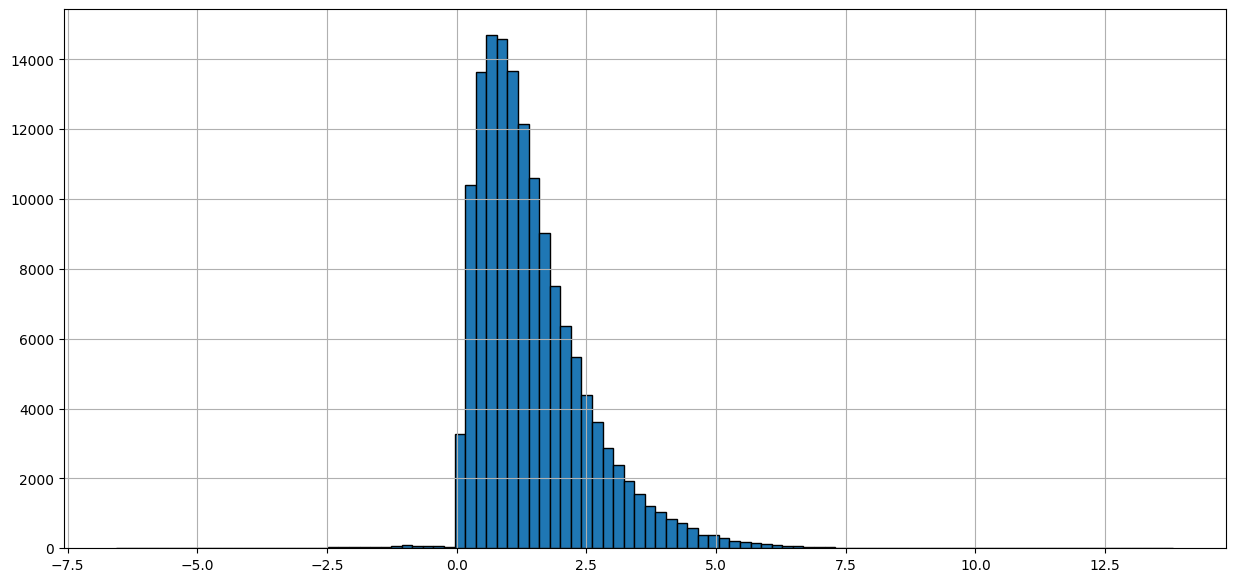

In [34]:
# kWh DISTRIBUTION
df["kwh"].hist(bins=100, figsize=(15, 7), edgecolor="black")

<Axes: >

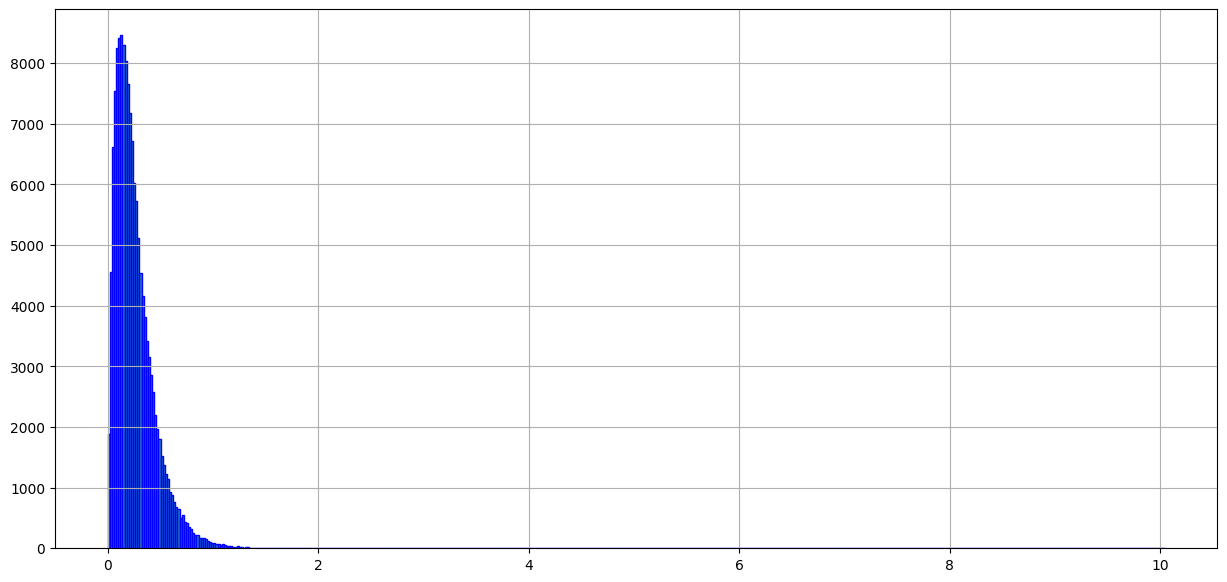

In [39]:
# BILL AMOUNT DISTRIBUTION
df["bill_amount_eur"].hist(bins=500, figsize=(15, 7), edgecolor="blue")

In [40]:
# MISSING VALUES SUMMARY
df.isnull().sum().sort_values(ascending=False)

region                     2948
customer_id                   0
meter_id                      0
timestamp_utc                 0
kwh                           0
tariff_plan                   0
is_smart_meter                0
outage_minutes_last_24h       0
bill_amount_eur               0
complaint_flag                0
dtype: int64

### 📝 Observations (Exploration Summary)

### **1. Row grain**
Each row represents **one hourly meter reading per customer**.  
Columns include consumption (`kwh`), outages, tariff type, billing amount, and complaint flag.

### **2. Immediate data issues**
- **Negative kWh values** → invalid sensor readings  
- **Missing regions** → likely incomplete customer metadata  
- **Duplicate rows** → warehouse export duplication  
- **Extreme bill amounts** → outliers (likely errors)  
- **Inconsistent timestamps** → need normalization  

### **3. Business levers visible**
- **Tariff type**: fixed vs variable  
- **Region**: North, South, East, West  
- **Smart meter adoption**  
- **Outage minutes**  
- **Billing amount**  
- **Complaint flag**  

These variables can influence customer satisfaction and operational cost.

### **4. Questions for stakeholders**
1. Are negative kWh readings expected from the metering system?  
2. Should missing regions be imputed or treated as “Unknown”?  
3. What is the billing cycle? Hourly readings aggregated to monthly bills?  
4. What constitutes a “high outage” day?  
5. Are complaint flags tied to billing periods or real‑time events?  
6. Are extreme bill values legitimate (e.g., industrial customers) or errors?  

### **5. Assumptions (to validate later)**
- Negative kWh = invalid → treat as missing  
- Missing region = “Unknown” category  
- Outlier bills should be capped  
- Complaint flag is binary per reading but will be aggregated per day  
- Outage minutes represent rolling 24‑hour window  

---